This notebook investigates non interacting cell types.
Specifically: 
Ciliated Pseudostratified Epithelial Cells (lining the airways):
- FOXJ1 (The master regulator and most reliable marker for ciliated cells)
- CAPS, PIFO, TPPP3, SNTN
Alveolar Type I (AT1) Pneumocytes (thin cells mediating gas exchange):
- AGER (RAGE)
- HOPX, PDPN, AQP5
Alveolar Type II (AT2) Pneumocytes (cuboidal cells secreting surfactant):
- SFTPC (Surfactant Protein C - highly specific)
- SFTPB, SFTPD, ABCA3, SLC34A2

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

import spatialdata as sd
import scanpy as sc

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:


# 1. Load the data using spatialdata instead of anndata
zarr_path = "/home/ktang/single_cell/data/zarr_outputs_no_images/H_Xenium_Preview_Human_Non_diseased_Lung_With_Add_on_FFPE_outs_Human.zarr"
sdata = sd.read_zarr(zarr_path)

# Look at the rich spatial data structure!
print(sdata)

# 2. Extract the AnnData table 
# (This contains your cell-by-gene matrix for the marker gene scoring)
adata = sdata.tables["table"]

# Verify we got the AnnData object out safely
print(adata)

SpatialData object, with associated Zarr store: /home/ktang/single_cell/data/zarr_outputs_no_images/H_Xenium_Preview_Human_Non_diseased_Lung_With_Add_on_FFPE_outs_Human.zarr
├── Labels
│     ├── 'cell_labels': DataTree[yx] (47696, 51148), (23848, 25574), (11924, 12787), (5962, 6393), (2981, 3196)
│     └── 'nucleus_labels': DataTree[yx] (47696, 51148), (23848, 25574), (11924, 12787), (5962, 6393), (2981, 3196)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (295883, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (295883, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (295883, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (295883, 392)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)
AnnData 

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


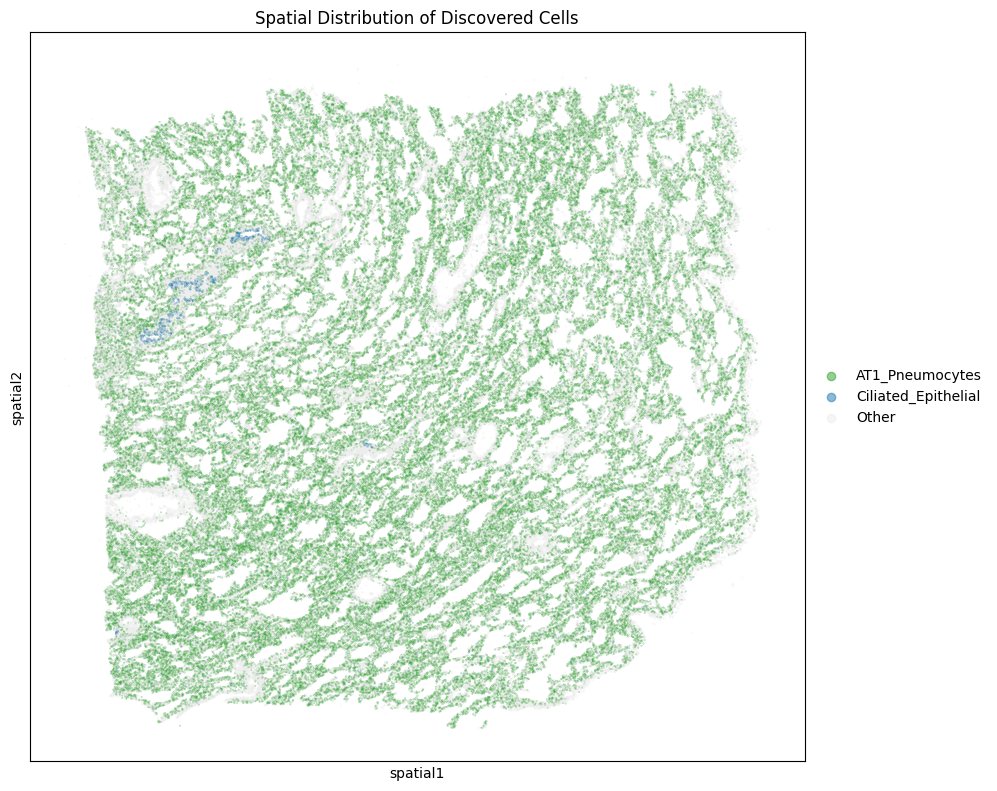

In [3]:
markers = {
    'Ciliated_Epithelial': ['FOXJ1', 'CAPS', 'PIFO', 'TPPP3'],
    'AT1_Pneumocytes': ['AGER', 'HOPX', 'PDPN', 'AQP5'],
    'AT2_Pneumocytes': ['SFTPC', 'SFTPB', 'ABCA3']
}

# 3. Basic Preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 4. Score cells based on marker sets AND track successes
scored_cell_types = [] # New list to keep track of what worked

for cell_type, genes in markers.items():
    valid_genes = [g for g in genes if g in adata.var_names]
    if not valid_genes:
        print(f"Warning: No genes found for {cell_type} in this dataset. Skipping.")
        continue # Skip to the next cell type
    
    # If we have valid genes, score them and record the success
    sc.tl.score_genes(adata, gene_list=valid_genes, score_name=f"{cell_type}_score")
    scored_cell_types.append(cell_type)

# Safety check in case NO genes from ANY cell type were found
if not scored_cell_types:
    raise ValueError("No marker genes were found for any cell types. Check your panel var_names!")

# 5. Quick Cell Type Assignment
score_cols = [f"{ct}_score" for ct in scored_cell_types]
scores_df = adata.obs[score_cols]

threshold = 0.5 
adata.obs['cell_type'] = 'Other'

max_scores = scores_df.max(axis=1)
max_idx = scores_df.idxmax(axis=1)

for ct in scored_cell_types:
    score_name = f"{ct}_score"
    mask = (max_idx == score_name) & (max_scores > threshold)
    adata.obs.loc[mask, 'cell_type'] = ct

# --- NEW: Convert to Categorical ---
# Scanpy and Squidpy handle colors best when the data is formally categorical
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')

# 6. Spatial Visualization Color Fix
base_palette = {
    "Ciliated_Epithelial": "#1f77b4", # Blue
    "AT1_Pneumocytes": "#2ca02c",     # Green
    "AT2_Pneumocytes": "#d62728",     # Red
    "Other": "#ededed"                # Light Grey
}

# Create a list of colors that perfectly matches the order of our categories
categories = adata.obs['cell_type'].cat.categories
ordered_colors = [base_palette.get(cat, "#000000") for cat in categories]

# Save the colors natively into the AnnData object so Squidpy finds them automatically
adata.uns['cell_type_colors'] = ordered_colors

fig, ax = plt.subplots(figsize=(10, 10))

sq.pl.spatial_scatter(
    adata,
    color="cell_type",
    shape=None,  
    size=0.1,
    alpha=0.5,    
    # Notice we completely removed the 'palette=' argument here!
    ax=ax,
    title="Spatial Distribution of Discovered Cells"
)
plt.savefig("Lung_human_markers.png", dpi=600)
plt.show()

# Predict niches

In [4]:
from src.pipeline import predict_niches
adata = predict_niches(sdata, method="knn")
print(adata.obs["watershed_by_descent"].value_counts())

Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.
watershed_by_descent
23646    71
18034    63
34803    63
18353    60
45531    60
         ..
62128     1
62119     1
62124     1
62125     1
12        1
Name: count, Length: 62141, dtype: int64


In [5]:
import pandas as pd
import numpy as np

def score_niche_separation(
    adata,
    niche_key="watershed_by_descent",
    cell_type_key="cell_type",
    type_a="Ciliated_Epithelial",
    type_b="AT1_Pneumocytes",
    verbose=True
):
    """
    Score how well two cell types are separated across predicted niches.

    Returns
    -------
    niche_summary : pd.DataFrame
        One row per niche with counts and class labels.
    metrics : dict
        Summary metrics including raw counts and mixing scores.
    """

    df = adata.obs[[niche_key, cell_type_key]].copy()
    df = df.dropna()

    # Count cells per niche x cell type
    counts = (
        df.groupby([niche_key, cell_type_key])
          .size()
          .unstack(fill_value=0)
    )

    # Ensure columns exist even if one type is absent
    if type_a not in counts.columns:
        counts[type_a] = 0
    if type_b not in counts.columns:
        counts[type_b] = 0

    counts["n_a"] = counts[type_a]
    counts["n_b"] = counts[type_b]
    counts["total_cells_in_niche"] = counts.sum(axis=1)

    # Informative niches = niches containing at least one of either cell type
    counts["informative"] = (counts["n_a"] > 0) | (counts["n_b"] > 0)

    # Niche categories
    counts["is_mixed"] = (counts["n_a"] > 0) & (counts["n_b"] > 0)
    counts["is_pure_a"] = (counts["n_a"] > 0) & (counts["n_b"] == 0)
    counts["is_pure_b"] = (counts["n_b"] > 0) & (counts["n_a"] == 0)

    def classify(row):
        if row["is_mixed"]:
            return "mixed"
        elif row["is_pure_a"]:
            return f"pure_{type_a}"
        elif row["is_pure_b"]:
            return f"pure_{type_b}"
        else:
            return "other"

    counts["niche_class"] = counts.apply(classify, axis=1)

    informative = counts[counts["informative"]].copy()

    n_total_niches = counts.shape[0]
    n_informative = informative.shape[0]
    n_mixed = int(informative["is_mixed"].sum())
    n_pure_a = int(informative["is_pure_a"].sum())
    n_pure_b = int(informative["is_pure_b"].sum())

    # Primary metric: fraction of informative niches that are mixed
    mixed_fraction = n_mixed / n_informative if n_informative > 0 else np.nan

    # Cell-weighted contamination:
    # in each mixed niche, the smaller population is treated as contamination
    informative["minority_contamination"] = np.minimum(informative["n_a"], informative["n_b"])
    informative["a_plus_b_cells"] = informative["n_a"] + informative["n_b"]

    contamination_score = (
        informative["minority_contamination"].sum() / informative["a_plus_b_cells"].sum()
        if informative["a_plus_b_cells"].sum() > 0 else np.nan
    )

    # A "brilliant" interpretable separation score: 1 is perfect, 0 is terrible
    # combines niche-level purity and cell-level contamination
    separation_score = (
        (1 - mixed_fraction) * (1 - contamination_score)
        if pd.notna(mixed_fraction) and pd.notna(contamination_score)
        else np.nan
    )

    metrics = {
        "type_a": type_a,
        "type_b": type_b,
        "total_niches": n_total_niches,
        "informative_niches": n_informative,
        "mixed_niches": n_mixed,
        f"pure_{type_a}_niches": n_pure_a,
        f"pure_{type_b}_niches": n_pure_b,
        "mixed_fraction_of_informative_niches": mixed_fraction,
        "contamination_score": contamination_score,
        "separation_score": separation_score,
    }

    if verbose:
        print("=== Niche separation summary ===")
        for k, v in metrics.items():
            print(f"{k}: {v}")

    return counts.reset_index(), metrics

In [6]:
niche_summary, metrics = score_niche_separation(
    adata,
    niche_key="watershed_by_descent",
    cell_type_key="cell_type",
    type_a="Ciliated_Epithelial",
    type_b="AT1_Pneumocytes"
)

niche_summary.head()

=== Niche separation summary ===
type_a: Ciliated_Epithelial
type_b: AT1_Pneumocytes
total_niches: 62141
informative_niches: 41474
mixed_niches: 1554
pure_Ciliated_Epithelial_niches: 451
pure_AT1_Pneumocytes_niches: 39469
mixed_fraction_of_informative_niches: 0.03746925784829049
contamination_score: 0.015413741985032774
separation_score: 0.9476945416395209


cell_type,watershed_by_descent,AT1_Pneumocytes,Ciliated_Epithelial,Other,n_a,n_b,total_cells_in_niche,informative,is_mixed,is_pure_a,is_pure_b,niche_class
0,1,0,0,1,0,0,1,False,False,False,False,other
1,2,1,0,0,0,1,2,True,False,False,True,pure_AT1_Pneumocytes
2,3,4,0,14,0,4,22,True,False,False,True,pure_AT1_Pneumocytes
3,4,1,0,6,0,1,8,True,False,False,True,pure_AT1_Pneumocytes
4,5,1,0,1,0,1,3,True,False,False,True,pure_AT1_Pneumocytes


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_niche_purity_heatmap(
    adata,
    niche_key="watershed_by_descent",
    cell_type_key="cell_type",
    type_a="Ciliated_Epithelial",
    type_b="AT1_Pneumocytes",
    exclude_uninformative=True,
    figsize=(6, 5),
    cmap="Blues"
):
    """
    Plot a confusion-style purity heatmap for niche composition.

    Parameters
    ----------
    adata : AnnData
    niche_key : str
        Column in adata.obs containing niche IDs.
    cell_type_key : str
        Column in adata.obs containing cell type labels.
    type_a : str
        First cell type, shown on heatmap rows.
    type_b : str
        Second cell type, shown on heatmap columns.
    exclude_uninformative : bool
        If True, exclude niches containing neither type_a nor type_b
        from the displayed fraction denominator.
    figsize : tuple
    cmap : str

    Returns
    -------
    niche_summary : pd.DataFrame
        One row per niche with counts and logical membership.
    heatmap_counts : pd.DataFrame
        2x2 table of raw niche counts.
    heatmap_fraction : pd.DataFrame
        2x2 table of niche fractions.
    """

    df = adata.obs[[niche_key, cell_type_key]].copy().dropna()

    # count cells per niche x cell type
    counts = (
        df.groupby([niche_key, cell_type_key])
          .size()
          .unstack(fill_value=0)
    )

    if type_a not in counts.columns:
        counts[type_a] = 0
    if type_b not in counts.columns:
        counts[type_b] = 0

    niche_summary = pd.DataFrame(index=counts.index)
    niche_summary[f"{type_a}_count"] = counts[type_a]
    niche_summary[f"{type_b}_count"] = counts[type_b]
    niche_summary["has_a"] = niche_summary[f"{type_a}_count"] > 0
    niche_summary["has_b"] = niche_summary[f"{type_b}_count"] > 0

    if exclude_uninformative:
        niche_summary_plot = niche_summary[niche_summary["has_a"] | niche_summary["has_b"]].copy()
    else:
        niche_summary_plot = niche_summary.copy()

    # 2x2 confusion-style table
    heatmap_counts = pd.crosstab(
        niche_summary_plot["has_a"],
        niche_summary_plot["has_b"]
    ).reindex(index=[False, True], columns=[False, True], fill_value=0)

    total = heatmap_counts.values.sum()
    heatmap_fraction = heatmap_counts / total if total > 0 else heatmap_counts.astype(float)

    row_labels = [f"No {type_a}", f"Has {type_a}"]
    col_labels = [f"No {type_b}", f"Has {type_b}"]

    # ---- Plot raw counts ----
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap_counts.values, cmap=cmap)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(col_labels, rotation=20, ha="right")
    ax.set_yticklabels(row_labels)
    ax.set_title("Confusion-Style Niche Purity Heatmap (Raw Counts)")

    for i in range(2):
        for j in range(2):
            val = heatmap_counts.values[i, j]
            ax.text(j, i, f"{val}", ha="center", va="center", fontsize=12)

    plt.colorbar(im, ax=ax, label="Number of niches")
    plt.tight_layout()
    plt.show()

    # ---- Plot fractions ----
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap_fraction.values, cmap=cmap, vmin=0, vmax=max(heatmap_fraction.values.flatten()) if total > 0 else 1)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(col_labels, rotation=20, ha="right")
    ax.set_yticklabels(row_labels)
    ax.set_title("Confusion-Style Niche Purity Heatmap (Fractions)")

    for i in range(2):
        for j in range(2):
            val = heatmap_fraction.values[i, j]
            ax.text(j, i, f"{val:.2%}", ha="center", va="center", fontsize=12)

    plt.colorbar(im, ax=ax, label="Fraction of niches")
    plt.tight_layout()
    plt.show()

    return niche_summary.reset_index(), heatmap_counts, heatmap_fraction

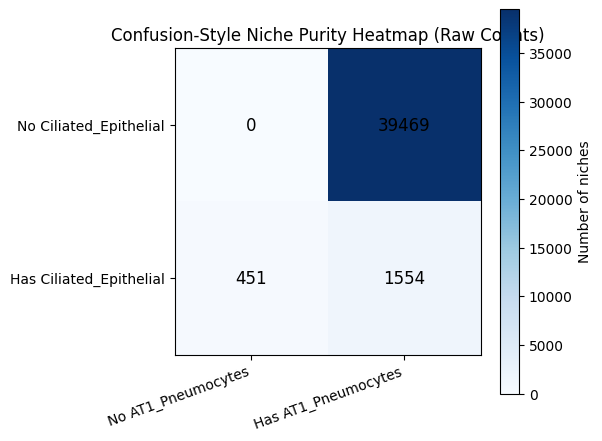

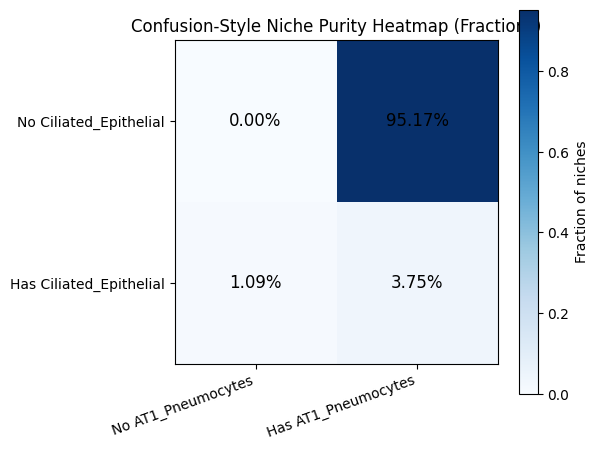

Raw counts:


has_b,False,True
has_a,,
False,0,39469
True,451,1554


Fractions:


has_b,False,True
has_a,,
False,0.000000,0.951656
True,0.010874,0.037469


In [9]:
niche_summary, heatmap_counts, heatmap_fraction = plot_niche_purity_heatmap(
    adata,
    niche_key="watershed_by_descent",
    cell_type_key="cell_type",
    type_a="Ciliated_Epithelial",
    type_b="AT1_Pneumocytes",
    exclude_uninformative=True
)

print("Raw counts:")
display(heatmap_counts)

print("Fractions:")
display(heatmap_fraction)

In [10]:
mixed_fraction = heatmap_fraction.loc[True, True]
print("Fraction of mixed niches:", mixed_fraction)

Fraction of mixed niches: 0.03746925784829049


# Comparing with KNN
Now I want to compare it to a ego KNN method. Niche = K nearest neighbors. 

In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
def compute_knn_niches(adata, k=10, coord_key="spatial"):
    """
    Compute ego-KNN niches (each cell defines a niche of itself + K neighbors)

    Returns
    -------
    niches : list[list[int]]
        list of cell indices for each niche
    """

    coords = adata.obsm[coord_key]

    nbrs = NearestNeighbors(n_neighbors=k+1)
    nbrs.fit(coords)

    distances, indices = nbrs.kneighbors(coords)

    # include the center cell itself
    niches = indices

    return niches

def score_knn_niches(
    adata,
    niches,
    cell_type_key="cell_type",
    type_a="Ciliated_Epithelial",
    type_b="AT1_Pneumocytes"
):
    
    cell_types = adata.obs[cell_type_key].values

    results = []

    for niche in niches:

        types = cell_types[niche]

        n_a = np.sum(types == type_a)
        n_b = np.sum(types == type_b)

        if n_a > 0 and n_b > 0:
            niche_class = "mixed"
        elif n_a > 0:
            niche_class = "pure_a"
        elif n_b > 0:
            niche_class = "pure_b"
        else:
            niche_class = "other"

        results.append((n_a, n_b, niche_class))

    df = pd.DataFrame(results, columns=["n_a","n_b","class"])

    return df

def summarize_knn_scores(df):

    informative = df[(df.n_a > 0) | (df.n_b > 0)]

    mixed = np.sum(informative["class"] == "mixed")
    pure_a = np.sum(informative["class"] == "pure_a")
    pure_b = np.sum(informative["class"] == "pure_b")

    mixed_fraction = mixed / len(informative)

    contamination = np.minimum(informative.n_a, informative.n_b).sum() / (
        informative.n_a + informative.n_b
    ).sum()

    separation_score = (1 - mixed_fraction) * (1 - contamination)

    print("=== KNN niche summary ===")
    print("informative niches:", len(informative))
    print("pure Ciliated:", pure_a)
    print("pure AT1:", pure_b)
    print("mixed:", mixed)
    print("mixed fraction:", mixed_fraction)
    print("contamination score:", contamination)
    print("separation score:", separation_score)

    return {
        "mixed_fraction": mixed_fraction,
        "contamination": contamination,
        "separation_score": separation_score
    }

Single KNN

In [12]:
# compute niches
niches = compute_knn_niches(adata, k=15)

# score niches
df_knn = score_knn_niches(adata, niches)

# summarize
metrics_knn = summarize_knn_scores(df_knn)

=== KNN niche summary ===
informative niches: 289235
pure Ciliated: 2321
pure AT1: 258069
mixed: 28845
mixed fraction: 0.0997285943955607
contamination score: 0.017759268755881904
separation score: 0.8842832437590745


Multiple KNN

In [16]:
results = []

for k in [2,5,10,20,30]:
    
    niches = compute_knn_niches(adata, k=k)
    df = score_knn_niches(adata, niches)
    metrics = summarize_knn_scores(df)

    metrics["k"] = k
    results.append(metrics)

results_df = pd.DataFrame(results)
results

=== KNN niche summary ===
informative niches: 204341
pure Ciliated: 4001
pure AT1: 196810
mixed: 3530
mixed fraction: 0.01727504514512506
contamination score: 0.0108647143011034
separation score: 0.9720479289838121
=== KNN niche summary ===
informative niches: 258346
pure Ciliated: 3785
pure AT1: 244667
mixed: 9894
mixed fraction: 0.038297477026932876
contamination score: 0.015252862848524808
separation score: 0.9470338062890786
=== KNN niche summary ===
informative niches: 282459
pure Ciliated: 2943
pure AT1: 259772
mixed: 19744
mixed fraction: 0.06990041032503833
contamination score: 0.01709086154880948
separation score: 0.9142033863612224
=== KNN niche summary ===
informative niches: 292080
pure Ciliated: 1825
pure AT1: 252917
mixed: 37338
mixed fraction: 0.12783483976992605
contamination score: 0.018055229018895447
separation score: 0.8564180185198184
=== KNN niche summary ===
informative niches: 294257
pure Ciliated: 1129
pure AT1: 240095
mixed: 53033
mixed fraction: 0.18022680853

[{'mixed_fraction': np.float64(0.01727504514512506),
  'contamination': np.float64(0.0108647143011034),
  'separation_score': np.float64(0.9720479289838121),
  'k': 2},
 {'mixed_fraction': np.float64(0.038297477026932876),
  'contamination': np.float64(0.015252862848524808),
  'separation_score': np.float64(0.9470338062890786),
  'k': 5},
 {'mixed_fraction': np.float64(0.06990041032503833),
  'contamination': np.float64(0.01709086154880948),
  'separation_score': np.float64(0.9142033863612224),
  'k': 10},
 {'mixed_fraction': np.float64(0.12783483976992605),
  'contamination': np.float64(0.018055229018895447),
  'separation_score': np.float64(0.8564180185198184),
  'k': 20},
 {'mixed_fraction': np.float64(0.18022680853811465),
  'contamination': np.float64(0.018429812830354712),
  'separation_score': np.float64(0.8046649249799003),
  'k': 30}]

Text(0.5, 1.0, 'KNN niche purity')

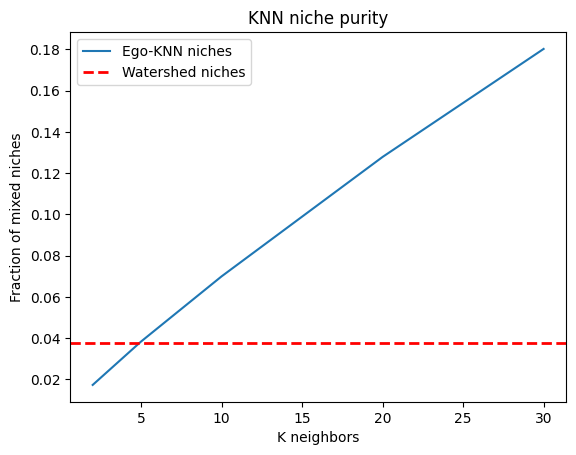

In [22]:
plt.plot(results_df.k, results_df.mixed_fraction, label="Ego-KNN niches")

plt.axhline(
    mixed_fraction,
    linestyle="--",
    linewidth=2,
    color="red",
    label="Watershed niches"
)
plt.xlabel("K neighbors")
plt.ylabel("Fraction of mixed niches")
plt.legend()
plt.title("KNN niche purity")

Watershed niche sizes

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_watershed_niche_sizes(
    adata,
    niche_key="watershed_by_descent",
    bins=50
):
    """
    Plot distribution of watershed niche sizes with mean and median.
    """

    # count cells per niche
    niche_sizes = adata.obs[niche_key].value_counts()

    mean_size = niche_sizes.mean()
    median_size = niche_sizes.median()

    fig, ax = plt.subplots(figsize=(7,5))

    ax.hist(niche_sizes, bins=bins, alpha=0.7)

    # mean line
    ax.axvline(
        mean_size,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_size:.2f}"
    )

    # median line
    ax.axvline(
        median_size,
        linestyle="-",
        linewidth=2,
        label=f"Median = {median_size:.2f}"
    )

    ax.set_xlabel("Watershed niche size (# cells)")
    ax.set_ylabel("Number of niches")
    ax.set_title("Distribution of Watershed Niche Sizes")

    ax.legend()

    plt.tight_layout()
    plt.show()

    print("Summary statistics:")
    print(f"Total niches: {len(niche_sizes)}")
    print(f"Mean size: {mean_size:.2f}")
    print(f"Median size: {median_size:.2f}")
    print(f"Min size: {niche_sizes.min()}")
    print(f"Max size: {niche_sizes.max()}")

    return niche_sizes

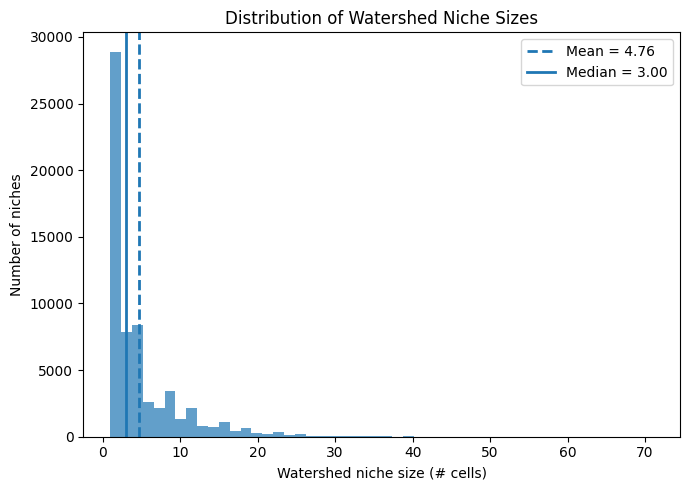

Summary statistics:
Total niches: 62141
Mean size: 4.76
Median size: 3.00
Min size: 1
Max size: 71


In [24]:
niche_sizes = plot_watershed_niche_sizes(adata)